# Training of the Skip-Gram model

In [1]:
from model import SkipGram, batch_generator, wordtoi, itoword
import matplotlib.pyplot as plt
import numpy as np
import pickle as pkl

## Parameters
Settings of parameters which I trained on. The parameters could have likely been tuned better, but due to the constrains of numpy it would take too long for experiments. I know that the learning rate looks high, but the loearning curve turned out okay.

In [ ]:
embedding_dimension = 100
batch_size = 256
eval_interval = 10
k = 15 # number of negative samples
steps = 12_000
max_window_size = 5
max_learning_rate = 10
min_learning_rate = max_learning_rate/20

In [3]:
word_model = SkipGram(vocab_size=len(wordtoi), emb_dim=embedding_dimension)
batch = batch_generator(batch_size= batch_size, k= k, max_window_size= max_window_size)


## Training loop
on every eval_intervals I calculated the loss in order to see the training history. I also added a running loss (exponential average) so I could monitor if everything was fine. The linear learning rate was used so that the model could take bigger steps in the beginning, and thus speed up the training. Its also worth mentioning that on each step the model sets the gradients to zero, calculates the gradients, and applies them to the model. 

P.S. dont ask how long it took to train on the cpu ;(

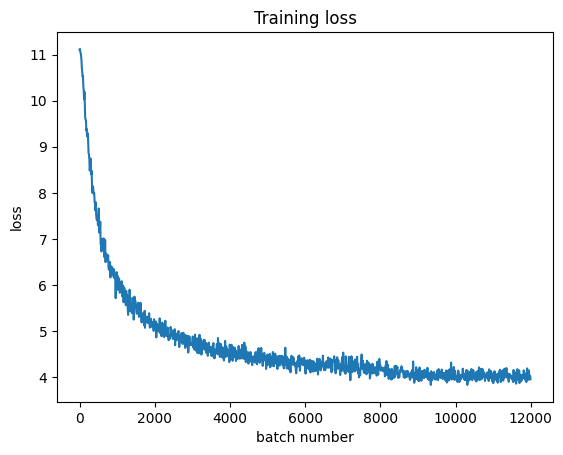

In [ ]:
history_x = []
history_y = []
for i in range(steps):
    word_model.zero_grad()
    x, y = next(batch)
    if i%eval_interval == 0:
        history_x.append(i)
        history_y.append(word_model.forward(x, y, calculate_loss= True))
        running_loss = history_y[-1] if i==0 else 0.95*running_loss + 0.05*history_y[-1]
    else:
        word_model.forward(x, y)

    word_model.backward(x, y)
    #linear learning rate decay
    lr = max((steps-i)*max_learning_rate/steps, min_learning_rate)
    word_model.update(lr)
    print(f"Batch {i+1:10}/{steps}, running loss= {running_loss:10.4f}", end="\r")

np.save("embeddings/embeddings.npy", word_model.target_embedding)
with open("embeddings/wordtoi.pkl", 'wb') as file:
    pkl.dump(wordtoi, file)

plt.plot(history_x, history_y)
plt.xlabel("batch number")
plt.ylabel("loss")
plt.title("Training loss")
plt.show()

In [16]:
# loading the saved embeddings and the word dictionary after training
embeddings = np.load("embeddings/embeddings.npy")
with open("embeddings/wordtoi.pkl", "rb") as f:
    wordtoi = pkl.load(f)
itoword = {i:word for word, i in wordtoi.items()}

## Word search
As a metric for word similarity I used the cosine similarity. The function closest_words returns a list of all the words in the embedding sorted based on how close they are to the given word

In [13]:
def cos_sim(a,b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
def closest_words(a):
    res = []
    for i in range(embeddings.shape[0]):
        sim = cos_sim(embeddings[i], embeddings[wordtoi[a]])
        res.append((sim,itoword[i]))
    res.sort(key = lambda x: x[0], reverse=True)

    return list(dict(res).values())

Not all words generate meaningful results, so theese are some that worked fine. I think that its probably because i didnt use the whole text8 dataset, only the beginning, so therefore the contents are highly biased to the types of given words. This could probably be fixed by using the whole dataset and further tuning the hyperparams.

In [17]:
for word in ["king", "war", "city", "army", "century", "church", "france"]:
    print(f"The closest 5 words to the word '{word}' are: " + ", ".join("'" + word + "'" for word in closest_words(word)[1:6]))

The closest 5 words to the word 'king' are: 'son', 'emperor', 'alexander', 'england', 'iv'
The closest 5 words to the word 'war' are: 'during', 'world', 'germany', 'military', 'civil'
The closest 5 words to the word 'city' are: 'capital', 'area', 'town', 'berlin', 'cities'
The closest 5 words to the word 'army' are: 'band', 'soviet', 'congress', 'member', 'governor'
The closest 5 words to the word 'century' are: 'th', 'early', 'centuries', 'late', 'bc'
The closest 5 words to the word 'church' are: 'roman', 'christian', 'the', 'religious', 'part'
The closest 5 words to the word 'france' are: 'germany', 'election', 'treaty', 'england', 'russia'
